# Buck Converter 최적 듀티 생성 + 신경망 보상 ON/OFF

실행 순서

1. `COMPENSATOR_MODE = "OFF"`로 실행하여 학습 CSV를 생성합니다.
2. 별도의 학습 노트북으로 `results/duty_compensator.pt`를 생성합니다.
3. `COMPENSATOR_MODE = "ON"`으로 변경하여 신경망 보상 결과를 확인합니다.

In [17]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -------------------------------------------------------------------------
# 사용자가 설정할 부분
# -------------------------------------------------------------------------
COMPENSATOR_MODE = "OFF"       # "OFF" 또는 "ON"

VIN = 48.0
VREF_LIST = [8.0, 12.0, 18.0, 24.0, 30.0]
IOUT_LIST = np.arange(1.0, 11.0, 1.0)

# 비선형 요소 1: 전류에 따른 등가 도통저항 증가
R0 = 0.06
K_R = 0.8
I_MAX = 10.0

# 비선형 요소 2: 전류에 따른 다이오드 전압강하 증가
VD0 = 0.50
K_D = 0.08

# 반복 듀티 보정 설정
DUTY_GAIN = 0.50
MAX_ITER = 20
VOLTAGE_TOL = 1e-4

# 저장 폴더와 파일
# Colab에서는 /content/data, 로컬에서는 현재 작업 폴더/data에 저장됩니다.
WORK_DIR = Path.cwd()
DATA_DIR = WORK_DIR / "data"
RESULTS_DIR = WORK_DIR / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "buck_optimal_duty_50points.csv"
MODEL_PATH = RESULTS_DIR / "duty_compensator.pt"

MODE = COMPENSATOR_MODE.strip().upper()
if MODE not in {"OFF", "ON"}:
    raise ValueError('COMPENSATOR_MODE는 "OFF" 또는 "ON"이어야 합니다.')

HISTORY_PATH = DATA_DIR / f"buck_convergence_history_{MODE.lower()}.csv"
CONVERGENCE_FIG_PATH = RESULTS_DIR / f"buck_duty_convergence_{MODE.lower()}.png"
NN_FIG_PATH = RESULTS_DIR / "nn_compensation_result.png"
ZIP_PATH = RESULTS_DIR / f"buck_duty_outputs_{MODE.lower()}.zip"

# CSV 컬럼 순서를 고정합니다. 학습 정답인 delta_duty를 앞쪽에 배치해
# 저장 파일에서 바로 확인할 수 있도록 했습니다.
CSV_COLUMNS = [
    "point_id",
    "v_ref_v",
    "i_out_a",
    "duty_ff",
    "duty_opt",
    "delta_duty",
    "mode",
    "v_out_at_ff_v",
    "ff_error_v",
    "delta_duty_nn",
    "duty_start",
    "v_out_at_start_v",
    "start_error_v",
    "v_out_final_v",
    "final_error_v",
    "correction_iterations",
]

print("Compensator mode:", MODE)
print("Data folder:", DATA_DIR)
print("50-point CSV path:", DATA_PATH)
print("Model path:", MODEL_PATH)

Compensator mode: OFF
Data folder: c:\Users\HP\Documents\GitHub\BuckConvExample\data
50-point CSV path: c:\Users\HP\Documents\GitHub\BuckConvExample\data\buck_optimal_duty_50points.csv
Model path: c:\Users\HP\Documents\GitHub\BuckConvExample\results\duty_compensator.pt


## 1. 간단한 비선형 Buck 모델

$$V_o=D V_{in}-I_oR_{loss}(I_o)-(1-D)V_D(I_o)$$

비선형 요소는 등가 도통저항과 다이오드 전압강하 두 가지만 사용합니다.

In [18]:
def resistance_loss(i_out):
    return R0 * (1.0 + K_R * (i_out / I_MAX) ** 2)


def diode_voltage(i_out):
    return VD0 + K_D * np.sqrt(i_out)


def buck_output_voltage(duty, i_out):
    r_loss = resistance_loss(i_out)
    v_diode = diode_voltage(i_out)

    return (
        duty * VIN
        - i_out * r_loss
        - (1.0 - duty) * v_diode
    )

## 2. 신경망 Delta Duty 보상기 로드

- `OFF`: $\Delta D_{NN}=0$
- `ON`: `results/duty_compensator.pt`에서 $\Delta D_{NN}$을 추론

ON 모드인데 모델 파일이 없으면 Colab 파일 업로드 창이 열립니다.

In [19]:
def load_delta_duty_predictor():
    if MODE == "OFF":
        return lambda v_ref, i_out: 0.0

    if not MODEL_PATH.exists():
        try:
            from google.colab import files

            print(f"{MODEL_PATH} 파일을 업로드하세요.")
            uploaded = files.upload()
            if not uploaded:
                raise FileNotFoundError("모델 파일이 업로드되지 않았습니다.")

            uploaded_name = next(iter(uploaded))
            MODEL_PATH.write_bytes(uploaded[uploaded_name])
            print("모델 저장 완료:", MODEL_PATH)
        except ImportError as exc:
            raise FileNotFoundError(
                f"{MODEL_PATH}가 없습니다. 먼저 학습 노트북을 실행하세요."
            ) from exc

    import torch
    import torch.nn as nn

    class DutyCompensator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(2, 8),
                nn.ReLU(),
                nn.Linear(8, 8),
                nn.ReLU(),
                nn.Linear(8, 1),
            )

        def forward(self, x):
            return self.net(x)

    checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
    model = DutyCompensator()
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    x_mean = np.asarray(checkpoint["x_mean"], dtype=np.float32)
    x_std = np.asarray(checkpoint["x_std"], dtype=np.float32)
    y_mean = float(checkpoint["y_mean"])
    y_std = float(checkpoint["y_std"])

    def predict(v_ref, i_out):
        x = np.array([[v_ref, i_out]], dtype=np.float32)
        x_normalized = (x - x_mean) / x_std

        with torch.no_grad():
            y_normalized = model(torch.from_numpy(x_normalized)).item()

        return y_normalized * y_std + y_mean

    return predict


predict_delta_duty = load_delta_duty_predictor()

## 3. 출력전압 오차를 이용한 반복 듀티 보정

OFF 모드는 이상적인 FF 듀티에서 시작합니다.

$$D_{start}=\frac{V_{ref}}{V_{in}}$$

ON 모드는 신경망이 예측한 Delta Duty를 더한 값에서 시작합니다.

$$D_{start}=\frac{V_{ref}}{V_{in}}+\Delta D_{NN}$$

이후 남은 전압오차로 듀티를 반복 보정합니다.

$$D_{k+1}=D_k+K_{corr}\frac{V_{ref}-V_o(k)}{V_{in}}$$

In [20]:
def converge_duty(v_ref, i_out, duty_start):
    duty = float(np.clip(duty_start, 0.0, 0.95))
    history = []

    for iteration in range(MAX_ITER + 1):
        v_out = buck_output_voltage(duty, i_out)
        error = v_ref - v_out

        history.append({
            "iteration": iteration,
            "duty": duty,
            "v_out_v": v_out,
            "voltage_error_v": error,
            "abs_error_v": abs(error),
        })

        if abs(error) < VOLTAGE_TOL:
            break

        duty += DUTY_GAIN * error / VIN
        duty = float(np.clip(duty, 0.0, 0.95))

    return duty, history

## 4. 50개 운전점 생성 및 `data` 폴더 저장

신경망 학습에 사용하는 핵심 열은 다음과 같습니다.

- 입력: `v_ref_v`, `i_out_a`
- 정답: `delta_duty`

In [21]:
summary_rows = []
history_rows = []
point_id = 0

for v_ref in VREF_LIST:
    for i_out in IOUT_LIST:
        point_id += 1

        duty_ff = v_ref / VIN
        v_out_ff = buck_output_voltage(duty_ff, i_out)

        delta_duty_nn = float(predict_delta_duty(v_ref, i_out))
        duty_start = float(np.clip(duty_ff + delta_duty_nn, 0.0, 0.95))
        v_out_start = buck_output_voltage(duty_start, i_out)

        duty_opt, point_history = converge_duty(v_ref, i_out, duty_start)
        v_out_final = buck_output_voltage(duty_opt, i_out)

        # FNN의 학습 정답: 이상적인 FF 듀티에 추가해야 하는 보상 듀티
        delta_duty = float(duty_opt - duty_ff)

        summary_rows.append({
            "point_id": point_id,
            "v_ref_v": v_ref,
            "i_out_a": i_out,
            "duty_ff": duty_ff,
            "duty_opt": duty_opt,
            "delta_duty": delta_duty,
            "mode": MODE,
            "v_out_at_ff_v": v_out_ff,
            "ff_error_v": v_ref - v_out_ff,
            "delta_duty_nn": delta_duty_nn,
            "duty_start": duty_start,
            "v_out_at_start_v": v_out_start,
            "start_error_v": v_ref - v_out_start,
            "v_out_final_v": v_out_final,
            "final_error_v": v_ref - v_out_final,
            "correction_iterations": len(point_history) - 1,
        })

        for item in point_history:
            history_rows.append({
                "point_id": point_id,
                "mode": MODE,
                "v_ref_v": v_ref,
                "i_out_a": i_out,
                **item,
            })

df = pd.DataFrame(summary_rows, columns=CSV_COLUMNS)
history_df = pd.DataFrame(history_rows)

# 저장 전 검증: 50포인트 및 delta_duty 컬럼을 반드시 보장합니다.
expected_points = len(VREF_LIST) * len(IOUT_LIST)
if len(df) != expected_points:
    raise RuntimeError(f"운전점 개수 오류: {len(df)}개 (예상 {expected_points}개)")
if "delta_duty" not in df.columns:
    raise RuntimeError("CSV에 delta_duty 컬럼이 없습니다.")

df.to_csv(DATA_PATH, index=False, float_format="%.8f")
history_df.to_csv(HISTORY_PATH, index=False, float_format="%.8f")

# 실제 저장 파일을 다시 읽어 경로와 컬럼을 한 번 더 확인합니다.
saved_df = pd.read_csv(DATA_PATH)
if list(saved_df.columns) != CSV_COLUMNS:
    raise RuntimeError("저장된 CSV 컬럼 구성이 예상과 다릅니다.")

print(df[["point_id", "v_ref_v", "i_out_a", "duty_ff", "duty_opt", "delta_duty"]])
print("\n50포인트 CSV 저장 완료:", DATA_PATH)
print("CSV 행 개수:", len(saved_df))
print("CSV 컬럼:", saved_df.columns.tolist())
print("수렴 이력 저장 완료:", HISTORY_PATH)

    point_id  v_ref_v  i_out_a   duty_ff  duty_opt  delta_duty
0          1      8.0      1.0  0.166667  0.177860    0.011193
1          2      8.0      2.0  0.166667  0.179723    0.013057
2          3      8.0      3.0  0.166667  0.181573    0.014906
3          4      8.0      4.0  0.166667  0.183531    0.016865
4          5      8.0      5.0  0.166667  0.185682    0.019015
5          6      8.0      6.0  0.166667  0.188097    0.021431
6          7      8.0      7.0  0.166667  0.190842    0.024176
7          8      8.0      8.0  0.166667  0.193981    0.027314
8          9      8.0      9.0  0.166667  0.197576    0.030909
9         10      8.0     10.0  0.166667  0.201688    0.035021
10        11     12.0      1.0  0.250000  0.260198    0.010198
11        12     12.0      2.0  0.250000  0.262006    0.012006
12        13     12.0      3.0  0.250000  0.263812    0.013812
13        14     12.0      4.0  0.250000  0.265735    0.015735
14        15     12.0      5.0  0.250000  0.267853    0

## 5. 현재 모드의 수렴 과정 Plot

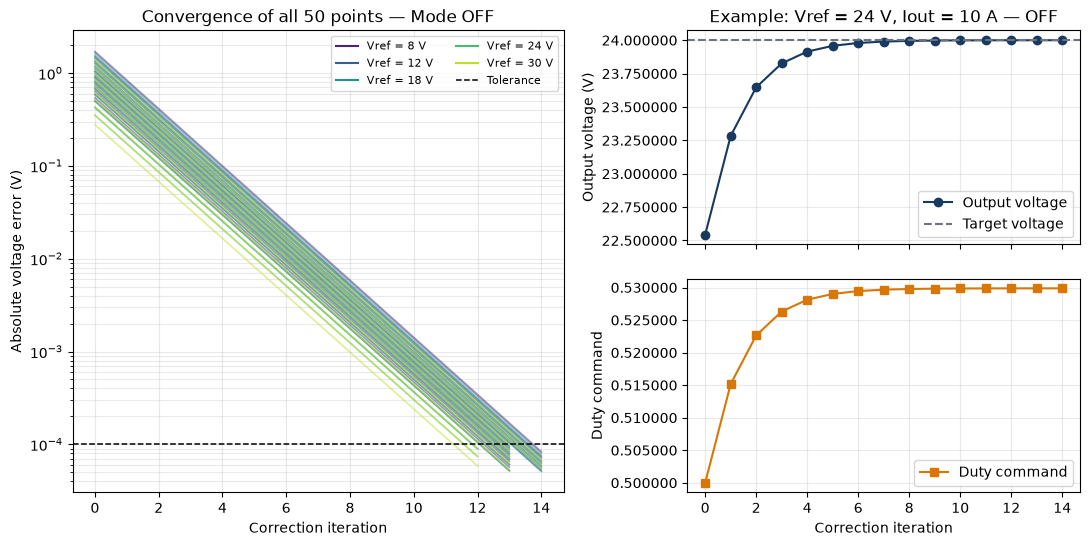

수렴 그래프 저장 완료: c:\Users\HP\Documents\GitHub\BuckConvExample\results\buck_duty_convergence_off.png


In [22]:
colors = plt.cm.viridis(np.linspace(0.10, 0.90, len(VREF_LIST)))
color_map = dict(zip(VREF_LIST, colors))

fig = plt.figure(figsize=(13, 6.0))
grid = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0], hspace=0.16, wspace=0.28)
ax_all = fig.add_subplot(grid[:, 0])
ax_voltage = fig.add_subplot(grid[0, 1])
ax_duty = fig.add_subplot(grid[1, 1], sharex=ax_voltage)

for _, group in history_df.groupby("point_id"):
    v_ref = group["v_ref_v"].iloc[0]
    ax_all.semilogy(
        group["iteration"],
        np.maximum(group["abs_error_v"], 1e-8),
        color=color_map[v_ref],
        alpha=0.48,
        linewidth=1.2,
    )

for v_ref in VREF_LIST:
    ax_all.plot([], [], color=color_map[v_ref], label=f"Vref = {v_ref:.0f} V")

ax_all.axhline(VOLTAGE_TOL, color="black", linestyle="--", linewidth=1.1, label="Tolerance")
ax_all.set_xlabel("Correction iteration")
ax_all.set_ylabel("Absolute voltage error (V)")
ax_all.set_title(f"Convergence of all 50 points — Mode {MODE}")
ax_all.grid(True, which="both", alpha=0.28)
ax_all.legend(fontsize=8, ncol=2)

example = history_df[
    (history_df["v_ref_v"] == 24.0)
    & (history_df["i_out_a"] == 10.0)
]

ax_voltage.plot(example["iteration"], example["v_out_v"], "o-", color="#183A61", label="Output voltage")
ax_voltage.axhline(24.0, color="#6B7280", linestyle="--", label="Target voltage")
ax_voltage.set_ylabel("Output voltage (V)")
ax_voltage.set_title(f"Example: Vref = 24 V, Iout = 10 A — {MODE}")
ax_voltage.grid(True, alpha=0.28)
ax_voltage.legend(loc="lower right")
ax_voltage.tick_params(labelbottom=False)
ax_voltage.yaxis.set_major_formatter(FormatStrFormatter("%.6f"))

ax_duty.plot(example["iteration"], example["duty"], "s-", color="#D97706", label="Duty command")
ax_duty.set_xlabel("Correction iteration")
ax_duty.set_ylabel("Duty command")
ax_duty.grid(True, alpha=0.28)
ax_duty.legend(loc="lower right")
ax_duty.yaxis.set_major_formatter(FormatStrFormatter("%.6f"))

fig.savefig(CONVERGENCE_FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()
print("수렴 그래프 저장 완료:", CONVERGENCE_FIG_PATH)

## 6. ON 모드: 신경망 보상 결과 Plot

ON 모드일 때만 다음 두 결과를 추가로 표시합니다.

- 보상 전 FF 전압오차와 신경망 보상 후 시작 전압오차 비교
- 실제 Delta Duty와 신경망 예측 Delta Duty 비교

In [23]:
if MODE == "ON":
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    axes[0].semilogy(
        df["point_id"], np.maximum(np.abs(df["ff_error_v"]), 1e-8),
        "o-", color="#6B7280", label="Ideal FF"
    )
    axes[0].semilogy(
        df["point_id"], np.maximum(np.abs(df["start_error_v"]), 1e-8),
        "s-", color="#183A61", label="FF + NN delta duty"
    )
    axes[0].set_xlabel("Operating point ID")
    axes[0].set_ylabel("Initial absolute voltage error (V)")
    axes[0].set_title("Initial voltage error before/after NN compensation")
    axes[0].grid(True, which="both", alpha=0.28)
    axes[0].legend()

    axes[1].scatter(df["delta_duty"], df["delta_duty_nn"], s=32, alpha=0.75)
    lower = min(df["delta_duty"].min(), df["delta_duty_nn"].min())
    upper = max(df["delta_duty"].max(), df["delta_duty_nn"].max())
    axes[1].plot([lower, upper], [lower, upper], "k--", linewidth=1.2)
    axes[1].set_xlabel("Required delta duty")
    axes[1].set_ylabel("NN-predicted delta duty")
    axes[1].set_title("Delta-duty prediction at 50 operating points")
    axes[1].grid(True, alpha=0.28)

    fig.tight_layout()
    fig.savefig(NN_FIG_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    print("신경망 보상 그래프 저장 완료:", NN_FIG_PATH)

## 7. 결과 ZIP 다운로드

In [24]:
files_to_zip = [DATA_PATH, HISTORY_PATH, CONVERGENCE_FIG_PATH]

if MODE == "ON":
    files_to_zip.extend([MODEL_PATH, NN_FIG_PATH])

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in files_to_zip:
        if path.exists():
            zf.write(path, arcname=str(path.relative_to(WORK_DIR)))

print("결과 ZIP 저장 완료:", ZIP_PATH)

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except ImportError:
    pass

결과 ZIP 저장 완료: c:\Users\HP\Documents\GitHub\BuckConvExample\results\buck_duty_outputs_off.zip
